# EDA — dados educacionais
Objetivo: entender como os dados de cada tabela estão distribuídos e visualizá-los através de gráficos

## Instalando bibliotecas

In [1]:
!pip install polars
!pip install matplotlib
!pip install seaborn

## Importando bibliotecas

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns


## Análise inicial das tabelas

### Tabela aluno

#### Análise
Total de registros: 97044 ; Total de registros duplicados: 0 ; Total de registros nulos: bairro (68)

In [3]:
df_aluno = pl.read_parquet("../data/aluno")
print("Colunas: ", df_aluno.columns)
print("Tipos de dados: ", df_aluno.dtypes)
print("Total de registros: ", df_aluno.shape[0])
print("Total de registros duplicados: ", df_aluno.is_duplicated().sum())
print("Total de registros nulos: ", df_aluno.null_count())


Colunas:  ['id_aluno', 'id_turma', 'faixa_etaria', 'bairro']
Tipos de dados:  [Binary, Int64, String, Int64]
Total de registros:  97044
Total de registros duplicados:  0
Total de registros nulos:  shape: (1, 4)
┌──────────┬──────────┬──────────────┬────────┐
│ id_aluno ┆ id_turma ┆ faixa_etaria ┆ bairro │
│ ---      ┆ ---      ┆ ---          ┆ ---    │
│ u32      ┆ u32      ┆ u32          ┆ u32    │
╞══════════╪══════════╪══════════════╪════════╡
│ 0        ┆ 0        ┆ 0            ┆ 68     │
└──────────┴──────────┴──────────────┴────────┘


#### Tratamentos
Após verificar que existem 68 registros nulos (que não representa nem 0,1% dos dados), considerei removê-los por acreditar que não terá impacto nos passos seguintes

In [4]:
df_aluno = df_aluno.drop_nulls()
print("Total de registros: ", df_aluno.shape[0])
print("Total de registros nulos: ", df_aluno.null_count())

Total de registros:  96976
Total de registros nulos:  shape: (1, 4)
┌──────────┬──────────┬──────────────┬────────┐
│ id_aluno ┆ id_turma ┆ faixa_etaria ┆ bairro │
│ ---      ┆ ---      ┆ ---          ┆ ---    │
│ u32      ┆ u32      ┆ u32          ┆ u32    │
╞══════════╪══════════╪══════════════╪════════╡
│ 0        ┆ 0        ┆ 0            ┆ 0      │
└──────────┴──────────┴──────────────┴────────┘


#### Análise após tratamento
Total de registros:  96976

Total de registros duplicados:  0

### Tabela avaliacao

#### Análise
Total de registros: 221687

Total de registros duplicados: 6 

Total de registros nulos: frequencia (1734), disciplina_1 (34609), disciplina_2 (35931), disciplina_3 (221687), disciplina_4 (35462)

In [5]:
df_avaliacao = pl.read_parquet("../data/avaliacao")
print("Colunas: ", df_avaliacao.columns)
print("Tipos de dados: ", df_avaliacao.dtypes)
print("Total de registros: ", df_avaliacao.shape[0])
print("Total de registros duplicados: ", df_avaliacao.is_duplicated().sum())
print("Total de registros nulos: ", df_avaliacao.null_count())

Colunas:  ['id_aluno', 'id_turma', 'frequencia', 'bimestre', 'disciplina_1', 'disciplina_2', 'disciplina_3', 'disciplina_4']
Tipos de dados:  [Binary, Int64, Float64, String, Float64, Float64, Float64, Float64]
Total de registros:  221687
Total de registros duplicados:  6
Total de registros nulos:  shape: (1, 8)
┌──────────┬──────────┬────────────┬──────────┬─────────────┬────────────┬────────────┬────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_ ┆ disciplina ┆ disciplina ┆ disciplina │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ 1           ┆ _2         ┆ _3         ┆ _4         │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ ---         ┆ ---        ┆ ---        ┆ ---        │
│          ┆          ┆            ┆          ┆ u32         ┆ u32        ┆ u32        ┆ u32        │
╞══════════╪══════════╪════════════╪══════════╪═════════════╪════════════╪════════════╪════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 34609       ┆ 35931      ┆ 22168

#### Tratamento 1
Após verificar que existem 6 registros duplicados (que não representa nem 0,1% dos dados), considerei removê-los por acreditar que não terá impacto nos passos seguintes

In [6]:
df_avaliacao = df_avaliacao.unique(maintain_order=True)
print("Total de registros: ", df_avaliacao.shape[0])
print("Total de registros duplicados: ", df_avaliacao.is_duplicated().sum())
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros:  221684
Total de registros duplicados:  0
Total de registros nulos:  shape: (1, 8)
┌──────────┬──────────┬────────────┬──────────┬─────────────┬────────────┬────────────┬────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_ ┆ disciplina ┆ disciplina ┆ disciplina │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ 1           ┆ _2         ┆ _3         ┆ _4         │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ ---         ┆ ---        ┆ ---        ┆ ---        │
│          ┆          ┆            ┆          ┆ u32         ┆ u32        ┆ u32        ┆ u32        │
╞══════════╪══════════╪════════════╪══════════╪═════════════╪════════════╪════════════╪════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 34606       ┆ 35928      ┆ 221684     ┆ 35459      │
└──────────┴──────────┴────────────┴──────────┴─────────────┴────────────┴────────────┴────────────┘


#### Tratamento 2
Após verificar que 100% dos registros da coluna disciplina_3 são nulos, considerei removê-los por acreditar que não terá impacto nos passos seguintes

In [7]:
df_avaliacao = df_avaliacao.drop("disciplina_3")
print("Total de registros: ", df_avaliacao.shape[0])
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros:  221684
Total de registros nulos:  shape: (1, 7)
┌──────────┬──────────┬────────────┬──────────┬──────────────┬──────────────┬──────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_1 ┆ disciplina_2 ┆ disciplina_4 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════╪════════════╪══════════╪══════════════╪══════════════╪══════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 34606        ┆ 35928        ┆ 35459        │
└──────────┴──────────┴────────────┴──────────┴──────────────┴──────────────┴──────────────┘


#### Tratamento 3
Após verificar que 15,6% dos registros da coluna disciplina_1 são nulos, considerei substituí-los pela mediana das frequências

In [8]:
df_avaliacao = df_avaliacao.with_columns(
    pl.when(pl.col("disciplina_1").is_null())
    .then(pl.col("disciplina_1").median())
    .otherwise(pl.col("disciplina_1"))
)
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros nulos:  shape: (1, 7)
┌──────────┬──────────┬────────────┬──────────┬──────────────┬──────────────┬──────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_1 ┆ disciplina_2 ┆ disciplina_4 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════╪════════════╪══════════╪══════════════╪══════════════╪══════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 0            ┆ 35928        ┆ 35459        │
└──────────┴──────────┴────────────┴──────────┴──────────────┴──────────────┴──────────────┘


#### Tratamento 4
Após verificar que 16,2% dos registros da coluna disciplina_2 são nulos, considerei substituí-los pela mediana das frequências

In [9]:
df_avaliacao = df_avaliacao.with_columns(
    pl.when(pl.col("disciplina_2").is_null())
    .then(pl.col("disciplina_2").median())
    .otherwise(pl.col("disciplina_2"))
)
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros nulos:  shape: (1, 7)
┌──────────┬──────────┬────────────┬──────────┬──────────────┬──────────────┬──────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_1 ┆ disciplina_2 ┆ disciplina_4 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════╪════════════╪══════════╪══════════════╪══════════════╪══════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 0            ┆ 0            ┆ 35459        │
└──────────┴──────────┴────────────┴──────────┴──────────────┴──────────────┴──────────────┘


#### Tratamento 5
Após verificar que 15,9% dos registros da coluna disciplina_4 são nulos, considerei substituí-los pela mediana das frequências

In [10]:
df_avaliacao = df_avaliacao.with_columns(
    pl.when(pl.col("disciplina_4").is_null())
    .then(pl.col("disciplina_4").median())
    .otherwise(pl.col("disciplina_4"))
)
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros nulos:  shape: (1, 7)
┌──────────┬──────────┬────────────┬──────────┬──────────────┬──────────────┬──────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_1 ┆ disciplina_2 ┆ disciplina_4 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════╪════════════╪══════════╪══════════════╪══════════════╪══════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 0            ┆ 0            ┆ 0            │
└──────────┴──────────┴────────────┴──────────┴──────────────┴──────────────┴──────────────┘


#### Tratamento 6
Após verificar que 0,7% dos registros da coluna disciplina_4 são nulos, considerei substituí-los pela mediana das frequências. Apesar de ser um % muito baixo, faz sentido substituir os valores.

In [11]:
df_avaliacao = df_avaliacao.with_columns(
    pl.when(pl.col("frequencia").is_null())
    .then(pl.col("frequencia").median())
    .otherwise(pl.col("frequencia"))
)
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros nulos:  shape: (1, 7)
┌──────────┬──────────┬────────────┬──────────┬──────────────┬──────────────┬──────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_1 ┆ disciplina_2 ┆ disciplina_4 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════╪════════════╪══════════╪══════════════╪══════════════╪══════════════╡
│ 0        ┆ 0        ┆ 0          ┆ 0        ┆ 0            ┆ 0            ┆ 0            │
└──────────┴──────────┴────────────┴──────────┴──────────────┴──────────────┴──────────────┘


#### Tratamento 7
Após verificar que a disciplina_1 representa Língua Portuguesa, que a disciplina_2 representa Matemática e que a disciplina_4 representa Ciências, considerei renomeá-las para facilitar análises futuras.

In [12]:
df_avaliacao = df_avaliacao.rename(
    {
        "disciplina_1": "lingua_portuguesa",
        "disciplina_2": "matematica",
        "disciplina_4": "ciencias",
    }
)
print("Colunas: ", df_avaliacao.columns)

Colunas:  ['id_aluno', 'id_turma', 'frequencia', 'bimestre', 'lingua_portuguesa', 'matematica', 'ciencias']


### Tabela escola

#### Análise
Total de registros: 1558 ; Total de registros duplicados: 0 ; Total de registros nulos: 0

In [13]:
df_escola = pl.read_parquet("../data/escola")
print("Colunas: ", df_escola.columns)
print("Tipos de dados: ", df_escola.dtypes)
print("Total de registros: ", df_escola.shape[0])
print("Total de registros duplicados: ", df_escola.is_duplicated().sum())
print("Total de registros nulos: ", df_escola.null_count())

Colunas:  ['id_escola', 'bairro']
Tipos de dados:  [Int64, Int64]
Total de registros:  1558
Total de registros duplicados:  0
Total de registros nulos:  shape: (1, 2)
┌───────────┬────────┐
│ id_escola ┆ bairro │
│ ---       ┆ ---    │
│ u32       ┆ u32    │
╞═══════════╪════════╡
│ 0         ┆ 0      │
└───────────┴────────┘


### Tabela frequencia

#### Análise
Total de registros: 2727684 ; Total de registros duplicados: 2952 ; Total de registros nulos: 0

In [14]:
df_frequencia = pl.read_parquet("../data/frequencia")
print("Colunas: ", df_frequencia.columns)
print("Tipos de dados: ", df_frequencia.dtypes)
print("Total de registros: ", df_frequencia.shape[0])
print("Total de registros duplicados: ", df_frequencia.is_duplicated().sum())
print("Total de registros nulos: ", df_frequencia.null_count())

Colunas:  ['id_escola', 'id_aluno', 'id_turma', 'data_inicio', 'data_fim', 'disciplina', 'frequencia']
Tipos de dados:  [Int64, Binary, Int64, String, String, String, Float64]
Total de registros:  2727684
Total de registros duplicados:  2952
Total de registros nulos:  shape: (1, 7)
┌───────────┬──────────┬──────────┬─────────────┬──────────┬────────────┬────────────┐
│ id_escola ┆ id_aluno ┆ id_turma ┆ data_inicio ┆ data_fim ┆ disciplina ┆ frequencia │
│ ---       ┆ ---      ┆ ---      ┆ ---         ┆ ---      ┆ ---        ┆ ---        │
│ u32       ┆ u32      ┆ u32      ┆ u32         ┆ u32      ┆ u32        ┆ u32        │
╞═══════════╪══════════╪══════════╪═════════════╪══════════╪════════════╪════════════╡
│ 0         ┆ 0        ┆ 0        ┆ 0           ┆ 0        ┆ 0          ┆ 0          │
└───────────┴──────────┴──────────┴─────────────┴──────────┴────────────┴────────────┘


#### Tratamento 1
Após verificar que existem 2952 registros duplicados (o que representa 0,1% dos dados), considerei removê-los por acreditar que não terá impacto nos passos seguintes

In [15]:
df_frequencia = df_frequencia.unique(maintain_order=True)
print("Total de registros: ", df_frequencia.shape[0])
print("Total de registros duplicados: ", df_frequencia.is_duplicated().sum())
print("Total de registros nulos: ", df_frequencia.null_count())

Total de registros:  2726201
Total de registros duplicados:  0
Total de registros nulos:  shape: (1, 7)
┌───────────┬──────────┬──────────┬─────────────┬──────────┬────────────┬────────────┐
│ id_escola ┆ id_aluno ┆ id_turma ┆ data_inicio ┆ data_fim ┆ disciplina ┆ frequencia │
│ ---       ┆ ---      ┆ ---      ┆ ---         ┆ ---      ┆ ---        ┆ ---        │
│ u32       ┆ u32      ┆ u32      ┆ u32         ┆ u32      ┆ u32        ┆ u32        │
╞═══════════╪══════════╪══════════╪═════════════╪══════════╪════════════╪════════════╡
│ 0         ┆ 0        ┆ 0        ┆ 0           ┆ 0        ┆ 0          ┆ 0          │
└───────────┴──────────┴──────────┴─────────────┴──────────┴────────────┴────────────┘


#### Tratamento 2
Após remover a disciplina_3 na tabela avaliacao, considerei removê-la em frequencia para manter a coerência

In [16]:
df_frequencia = df_frequencia.filter(pl.col("disciplina") != "disciplina_3")
print("Total de registros: ", df_frequencia.shape[0])
print("Total de registros nulos: ", df_frequencia.null_count())

Total de registros:  2044731
Total de registros nulos:  shape: (1, 7)
┌───────────┬──────────┬──────────┬─────────────┬──────────┬────────────┬────────────┐
│ id_escola ┆ id_aluno ┆ id_turma ┆ data_inicio ┆ data_fim ┆ disciplina ┆ frequencia │
│ ---       ┆ ---      ┆ ---      ┆ ---         ┆ ---      ┆ ---        ┆ ---        │
│ u32       ┆ u32      ┆ u32      ┆ u32         ┆ u32      ┆ u32        ┆ u32        │
╞═══════════╪══════════╪══════════╪═════════════╪══════════╪════════════╪════════════╡
│ 0         ┆ 0        ┆ 0        ┆ 0           ┆ 0        ┆ 0          ┆ 0          │
└───────────┴──────────┴──────────┴─────────────┴──────────┴────────────┴────────────┘


#### Tratamento 3
Após verificar que a disciplina_1 representa Língua Portuguesa, que a disciplina_2 representa Matemática e que a disciplina_4 representa Ciências, na tabela avaliacao, considerei renomeá-las aqui também para manter a coerência e consistências dos dados.

In [17]:
df_frequencia = df_frequencia.with_columns(
    pl.when(pl.col("disciplina") == "disciplina_1")
    .then(pl.lit("lingua_portuguesa"))
    .when(pl.col("disciplina") == "disciplina_2")
    .then(pl.lit("matematica"))
    .when(pl.col("disciplina") == "disciplina_4")
    .then(pl.lit("ciencias"))
    .otherwise(pl.col("disciplina"))
    .alias("disciplina"),
)
print("Colunas: ", df_frequencia["disciplina"].head())

Colunas:  shape: (10,)
Series: 'disciplina' [str]
[
	"lingua_portuguesa"
	"ciencias"
	"matematica"
	"lingua_portuguesa"
	"ciencias"
	"matematica"
	"lingua_portuguesa"
	"ciencias"
	"lingua_portuguesa"
	"matematica"
]


### Tabela turma

#### Análise
Total de registros: 97044 ; Total de registros duplicados: 0 ; Total de registros nulos: 0

In [18]:
df_turma = pl.read_parquet("../data/turma")
print("Colunas: ", df_turma.columns)
print("Tipos de dados: ", df_turma.dtypes)
print("Total de registros: ", df_turma.shape[0])
print("Total de registros duplicados: ", df_turma.is_duplicated().sum())
print("Total de registros nulos: ", df_turma.null_count())

Colunas:  ['ano', 'id_turma', 'id_aluno']
Tipos de dados:  [Int64, Int64, Binary]
Total de registros:  97044
Total de registros duplicados:  0
Total de registros nulos:  shape: (1, 3)
┌─────┬──────────┬──────────┐
│ ano ┆ id_turma ┆ id_aluno │
│ --- ┆ ---      ┆ ---      │
│ u32 ┆ u32      ┆ u32      │
╞═════╪══════════╪══════════╡
│ 0   ┆ 0        ┆ 0        │
└─────┴──────────┴──────────┘


## Análise univariada e distribuições

### Faixa etária
À partir da análise do gráfico abaixo é possível analisar que mais da metade dos alunos, da prefeitura, estão faixa de 15-17 anos.

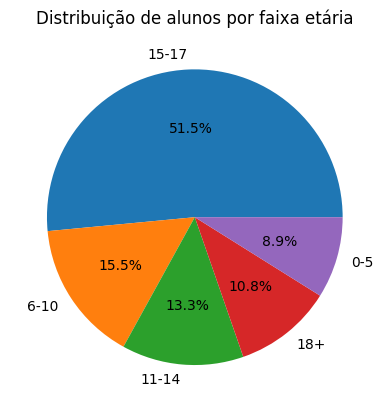

In [19]:
df_aluno_list = df_aluno["faixa_etaria"].value_counts(sort=True)
plt.figure()
plt.pie(
    df_aluno_list["count"],
    labels=df_aluno_list["faixa_etaria"],
    autopct="%1.1f%%",
)
plt.title("Distribuição de alunos por faixa etária")
plt.show()

### Bairro
Considerando que existem 1069 bairros cadastrados, decidi exibir os 10 bairros com o maior número de alunos

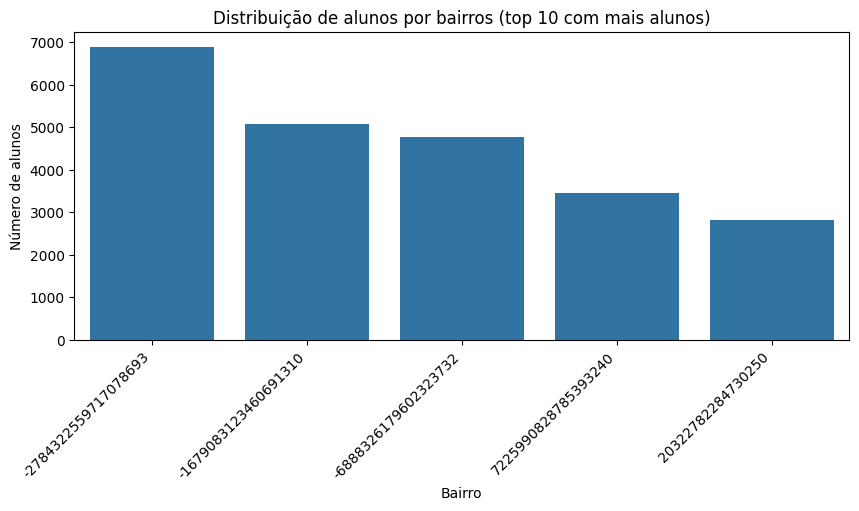

In [20]:
df_aluno_list = df_aluno["bairro"].value_counts(sort=True).head(5)
plt.figure(figsize=(10, 4))
sns.barplot(
    x=df_aluno_list["bairro"],
    y=df_aluno_list["count"],
    order=df_aluno_list["bairro"],
)
plt.title("Distribuição de alunos por bairros (top 10 com mais alunos)")
plt.xlabel("Bairro")
plt.ylabel("Número de alunos")
plt.xticks(rotation=45, ha="right")
plt.show()

### Frequência média por disciplina

In [21]:
df_frequencia_list = (
    df_frequencia.group_by("disciplina")
    .agg(pl.col("frequencia").mean().round(2))
    .sort("frequencia", descending=True)
)
print(df_frequencia_list)

shape: (3, 2)
┌───────────────────┬────────────┐
│ disciplina        ┆ frequencia │
│ ---               ┆ ---        │
│ str               ┆ f64        │
╞═══════════════════╪════════════╡
│ matematica        ┆ 99.94      │
│ ciencias          ┆ 99.91      │
│ lingua_portuguesa ┆ 99.9       │
└───────────────────┴────────────┘


### Nota média dos alunos em Língua Portuguesa
Considerando que a mediana é 6.64 e somando o % de alunos que estão abaixo ou muito abaixo da mediana, encontra-se 57.8% dos alunos nesta situação

Mediana em Língua Portuguesa:  6.64


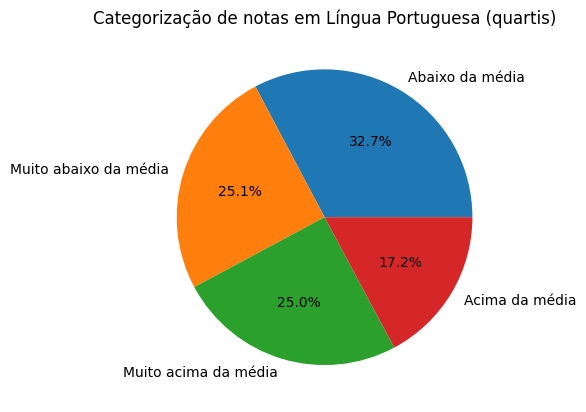

In [22]:
print("Mediana em Língua Portuguesa: ", df_avaliacao["lingua_portuguesa"].median())
df_avaliacao = df_avaliacao.with_columns(
    pl.col("lingua_portuguesa")
    .qcut(
        quantiles=4,
        labels=[
            "Muito abaixo da média",
            "Abaixo da média",
            "Acima da média",
            "Muito acima da média",
        ],
    )
    .alias("lingua_portuguesa_categoria")
)
vc = df_avaliacao["lingua_portuguesa_categoria"].value_counts(sort=True)
plt.figure()
plt.pie(
    vc["count"].to_list(),
    labels=[str(x) for x in vc["lingua_portuguesa_categoria"].to_list()],
    autopct="%1.1f%%",
)
plt.title("Categorização de notas em Língua Portuguesa (quartis)")
plt.show()

### Nota média dos alunos em Matemática
Considerando que a mediana é 6.19 e somando o % de alunos que estão abaixo ou muito abaixo da mediana, encontra-se 58.1% dos alunos nesta situação

Mediana em Matemática:  6.19


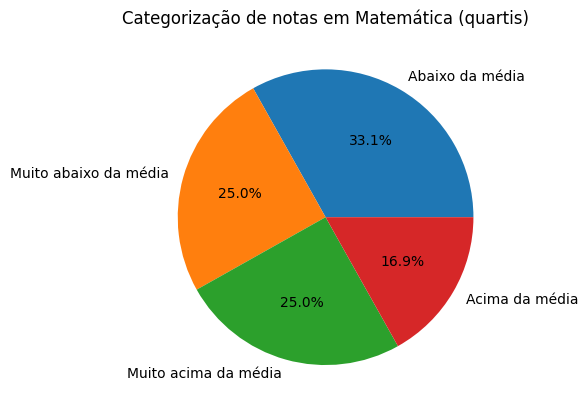

In [23]:
print("Mediana em Matemática: ", df_avaliacao["matematica"].median())
df_avaliacao = df_avaliacao.with_columns(
    pl.col("matematica")
    .qcut(
        quantiles=4,
        labels=[
            "Muito abaixo da média",
            "Abaixo da média",
            "Acima da média",
            "Muito acima da média",
        ],
    )
    .alias("matematica_categoria")
)
vc = df_avaliacao["matematica_categoria"].value_counts(sort=True)
plt.figure()
plt.pie(
    vc["count"].to_list(),
    labels=[str(x) for x in vc["matematica_categoria"].to_list()],
    autopct="%1.1f%%",
)
plt.title("Categorização de notas em Matemática (quartis)")
plt.show()

### Nota média dos alunos em Ciências
Considerando que a mediana é 5.79 e somando o % de alunos que estão abaixo ou muito abaixo da mediana, encontra-se 58% dos alunos nesta situação

Mediana em Ciências:  5.79


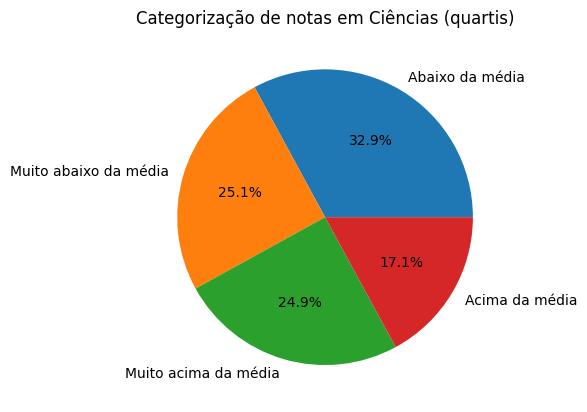

In [24]:
print("Mediana em Ciências: ", df_avaliacao["ciencias"].median())
df_avaliacao = df_avaliacao.with_columns(
    pl.col("ciencias")
    .qcut(
        quantiles=4,
        labels=[
            "Muito abaixo da média",
            "Abaixo da média",
            "Acima da média",
            "Muito acima da média",
        ],
    )
    .alias("ciencias_categoria")
)
vc = df_avaliacao["ciencias_categoria"].value_counts(sort=True)
plt.figure()
plt.pie(
    vc["count"].to_list(),
    labels=[str(x) for x in vc["ciencias_categoria"].to_list()],
    autopct="%1.1f%%",
)
plt.title("Categorização de notas em Ciências (quartis)")
plt.show()

## Análise Bivariada

### Nota média dos alunos por faixa etária em Língua Portuguesa
Os valores não preenchidos foram substituídos por 0.
À partir da análise abaixo é possível afirmar que:
- Os alunos de faixa etária 0-5 anos estão todos abaixo da média
- Os alunos de faixa etária 6-10 anos estão todos abaixo da média
- Os alunos de faixa etária 11-14 anos, em sua maioria, está abaixo da média
- Os alunos de faixa etária 15-17 anos se destacam por estarem, em sua maioria, muito acima da média
- Os alunos de faixa etária 18+ anos se destacam por estarem, em sua maioria, abaixo da média

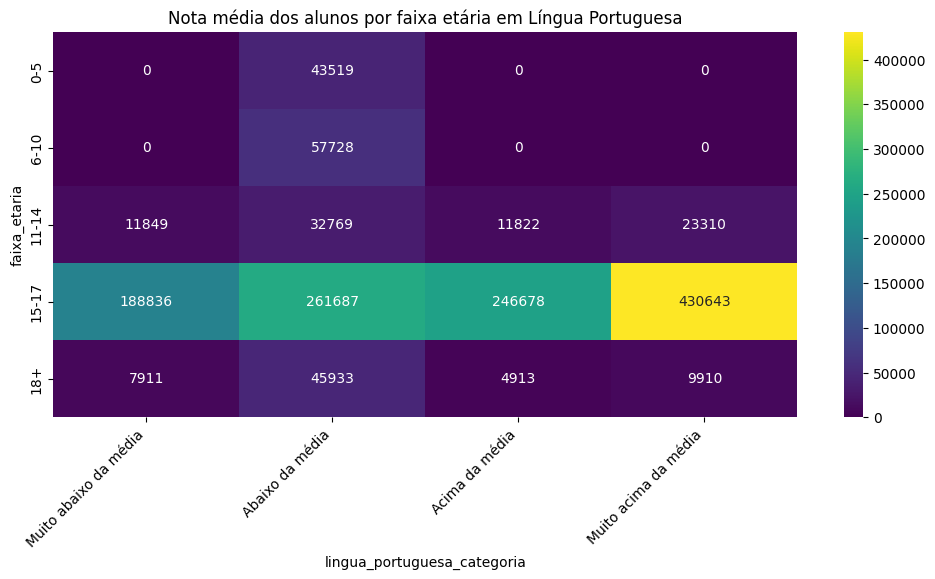

In [39]:
df_avaliacao_aluno = df_avaliacao.join(
    df_aluno, on=["id_aluno", "id_turma"], how="left"
)
pivot = df_avaliacao_aluno.to_pandas().pivot_table(
    index="faixa_etaria",
    columns="lingua_portuguesa_categoria",
    values="lingua_portuguesa",
    aggfunc="sum",
)
pivot = pivot.fillna(0)
pivot = pivot.reindex(["0-5", "6-10", "11-14", "15-17", "18+"])
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis")

plt.title("Nota média dos alunos por faixa etária em Língua Portuguesa")
plt.xticks(rotation=45, ha="right")
plt.show()

### Nota média dos alunos por faixa etária em Matemática
Os valores não preenchidos foram substituídos por 0.
À partir da análise abaixo é possível afirmar que:
- Os alunos de faixa etária 0-5 anos estão todos abaixo da média
- Os alunos de faixa etária 6-10 anos estão todos abaixo da média
- Os alunos de faixa etária 11-14 anos, em sua maioria, está abaixo da média
- Os alunos de faixa etária 15-17 anos se destacam por estarem, em sua maioria, muito acima da média
- Os alunos de faixa etária 18+ anos se destacam por estarem, em sua maioria, abaixo da média

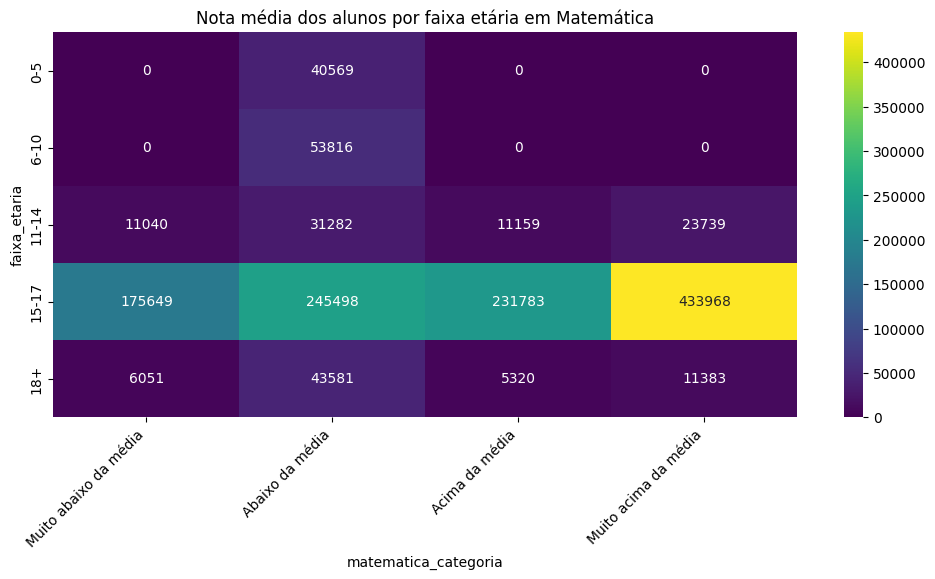

In [40]:
df_avaliacao_aluno = df_avaliacao.join(
    df_aluno, on=["id_aluno", "id_turma"], how="left"
)
pivot = df_avaliacao_aluno.to_pandas().pivot_table(
    index="faixa_etaria",
    columns="matematica_categoria",
    values="matematica",
    aggfunc="sum",
)
pivot = pivot.fillna(0)
pivot = pivot.reindex(["0-5", "6-10", "11-14", "15-17", "18+"])
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis")

plt.title("Nota média dos alunos por faixa etária em Matemática")
plt.xticks(rotation=45, ha="right")
plt.show()

### Nota média dos alunos por faixa etária em Língua Portuguesa
Os valores não preenchidos foram substituídos por 0.
À partir da análise abaixo é possível afirmar que:
- Os alunos de faixa etária 0-5 anos estão todos abaixo da média
- Os alunos de faixa etária 6-10 anos estão todos abaixo da média
- Os alunos de faixa etária 11-14 anos, em sua maioria, está abaixo da média (apesar da diferença para os alunos que estão muito acima da média ser pequena)
- Os alunos de faixa etária 15-17 anos se destacam por estarem, em sua maioria, muito acima da média
- Os alunos de faixa etária 18+ anos se destacam por estarem, em sua maioria, abaixo da média

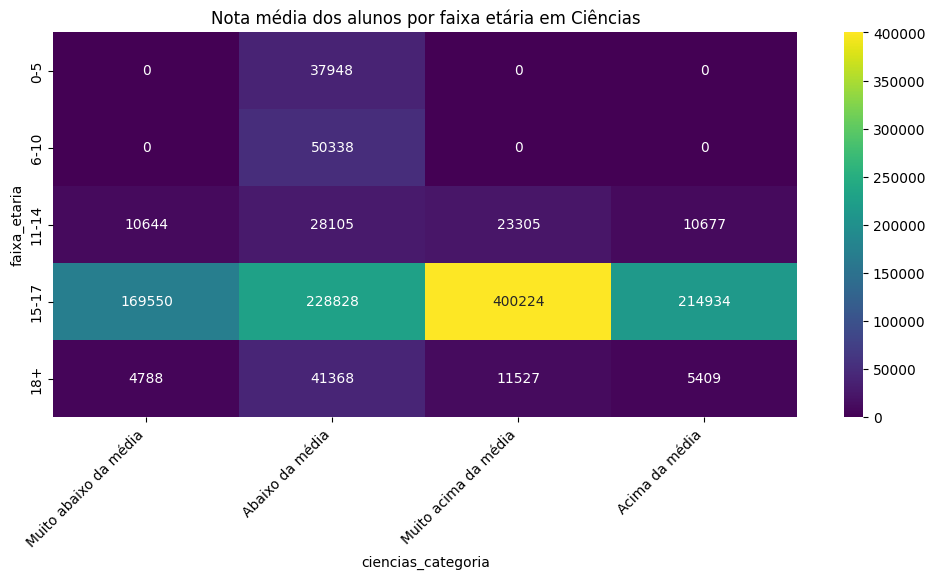

In [41]:
df_avaliacao_aluno = df_avaliacao.join(
    df_aluno, on=["id_aluno", "id_turma"], how="left"
)
pivot = df_avaliacao_aluno.to_pandas().pivot_table(
    index="faixa_etaria",
    columns="ciencias_categoria",
    values="ciencias",
    aggfunc="sum",
)
pivot = pivot.fillna(0)
pivot = pivot.reindex(["0-5", "6-10", "11-14", "15-17", "18+"])
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis")

plt.title("Nota média dos alunos por faixa etária em Ciências")
plt.xticks(rotation=45, ha="right")
plt.show()